## Initialization

In [3]:
import math

import numpy as np

import pandas as pd

import torch
import transformers

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

## Data Loading

In [6]:
df_reviews = pd.read_csv("C:\\Users\\ariex\\OneDrive\\Documents\\Repositories\\sentiment-prediction\\data\\imdb_reviews.tsv", sep='\t')

In [5]:
df_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  str    
 1   title_type       47331 non-null  str    
 2   primary_title    47331 non-null  str    
 3   original_title   47331 non-null  str    
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  str    
 6   runtime_minutes  47331 non-null  str    
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  str    
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  str    
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  str    
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  str    
 16  idx              47331 non-null  int64  
dtypes: Int64(1), float64(1)

## Data Preprocessing

In [6]:
# Removing NaN values from the dataset. Since the analysis showed only 2 rows contain missing values out of 47330 rows

reviews_clean = df_reviews.dropna()


In [7]:
# Verifying duplicated values

print(reviews_clean.duplicated().sum())


0


In [8]:
# Selecting columns to remove 

cols_model_extended = set(['review', 'pos', 'genres', 'average_rating', 'votes'])
columns_original = set(df_reviews.columns)
columns_removed = columns_original - cols_model_extended

print(columns_removed)


{'runtime_minutes', 'start_year', 'title_type', 'sp', 'end_year', 'ds_part', 'idx', 'rating', 'primary_title', 'original_title', 'tconst', 'is_adult'}


In [9]:
# Removing columns with low predictive value for sentiment analysis
# Keeping: review, pos, genres, average_rating, votes (features relevant to classification)

reviews_clean = reviews_clean.drop(columns=list(columns_removed))


Se conservaron únicamente las variables directamente relacionadas con el texto de la reseña, con el fin de evaluar el poder predictivo intrínseco de la información lingüística. Las columnas identificadoras, las variables redundantes y los metadatos contextuales fueron excluidos para evitar fuga de información, reducir el ruido y mantener la interpretabilidad del modelo.

### Verifying the quality of the reviews

In [10]:
# Verifying if there are empty reviews

empty_reviews = reviews_clean[reviews_clean['review'].str.strip() == '']
print("Empty reviews:", len(empty_reviews))


Empty reviews: 0


In [11]:
# Identifying duplicated reviews

reviews_clean['review'].duplicated().sum()


np.int64(91)

In [12]:
# Removing duplicated reviews

reviews_clean = reviews_clean.drop_duplicates(subset='review')

print(reviews_clean['review'].duplicated().sum())


0


In [13]:
# Analysing review length

reviews_lenght = reviews_clean['review'].str.len()
reviews_lenght.describe()


count    47238.000000
mean      1290.753228
std        975.472777
min         32.000000
25%        691.000000
50%        958.000000
75%       1567.000000
max      13594.000000
Name: review, dtype: float64

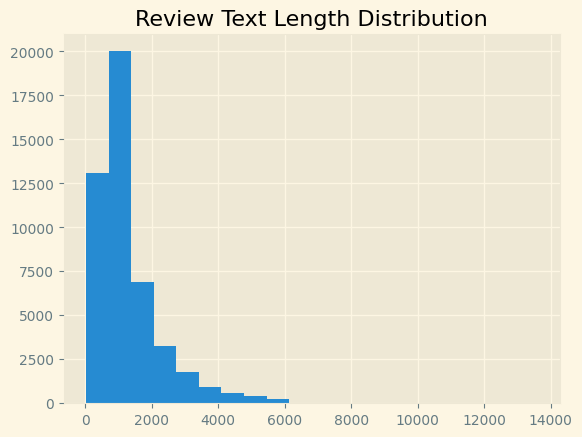

In [14]:
# Analyzing the distribution of reviews text length

plt.hist(reviews_lenght, bins=20)
plt.title('Review Text Length Distribution')
plt.show()


In [15]:
# Detecting URL and HTML tag contamination in review text

print(reviews_clean['review'].str.contains('http').sum())
print(reviews_clean['review'].str.contains('<.*?>').sum())


111
12


In [16]:
# Removing URLs and HTML tags using regex pattern matching

reviews_clean['review'] = reviews_clean['review'].str.replace(r'http\S+|<.*?>', '', regex=True)

reviews_clean.shape


(47238, 5)

In [17]:
# Confirming successful removal of URLs and HTML artifacts

print(reviews_clean['review'].str.contains('http').sum())
print(reviews_clean['review'].str.contains('<.*?>').sum())


0
0


In [18]:

df_model = reviews_clean[['review', 'pos']]

df_model_extended = reviews_clean.copy()

df_reviews = df_reviews.drop(columns=['idx', 'sp'])


Se trabajará con tres conjuntos de datos diseñados para distintos propósitos dentro del proyecto.

El primer conjunto, df_model, incluirá únicamente las variables review y pos, donde pos corresponde a la variable objetivo. Este conjunto se utilizará para entrenar el modelo base (baseline), permitiendo establecer un punto de referencia claro antes de incorporar variables adicionales o realizar optimizaciones más complejas.

El segundo conjunto, df_model_extended, contendrá todas las variables que, además del texto de la reseña, fueron consideradas con potencial predictivo. Este dataset permitirá evaluar si la incorporación de información estructurada (como características de la película) mejora el desempeño del modelo respecto al baseline.

Finalmente, el tercer conjunto, df_reviews, conservará la mayoría de las columnas originales y estará destinado exclusivamente al análisis exploratorio de datos (EDA). Esto permitirá analizar patrones, distribuciones y posibles relaciones entre variables sin afectar directamente el flujo de modelado.


## EDA

Número de películas y reseñas a lo largo de los años.

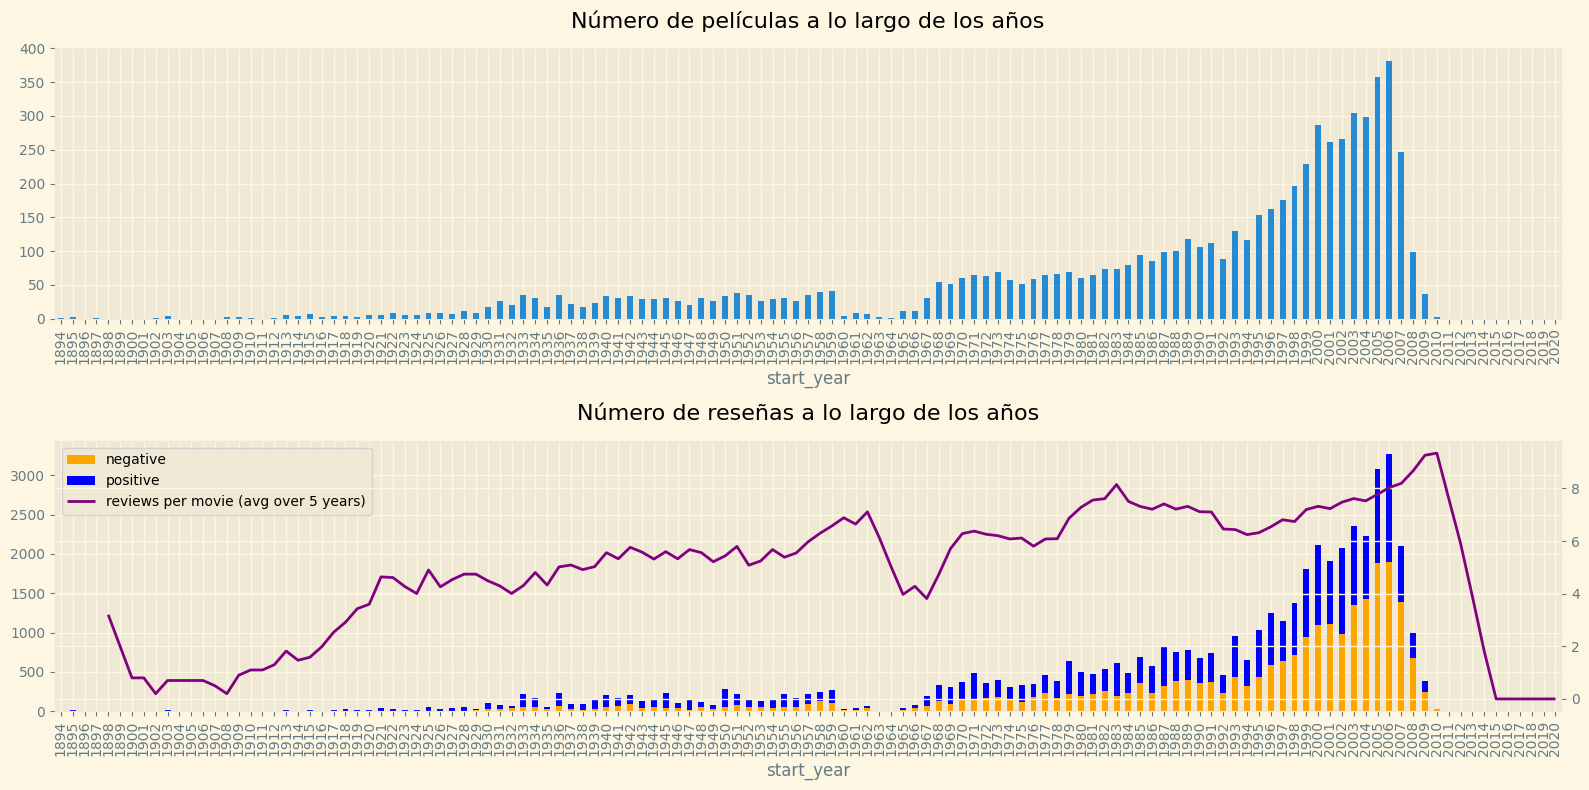

In [19]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(range(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de películas a lo largo de los años', pad=15)

ax2 = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(range(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft2.columns = ['negative', 'positive']

dft2.plot(kind='bar', stacked=True, color=['orange', 'blue'], label='#reviews (neg, pos)', ax=ax2)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(range(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax2.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='purple', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax2.legend(lines2 + lines, labels2 + labels, loc='upper left')

ax2.set_title('Número de reseñas a lo largo de los años', pad=15)

fig.tight_layout()


Distribución del número de reseñas por película con el conteo exacto y KDE

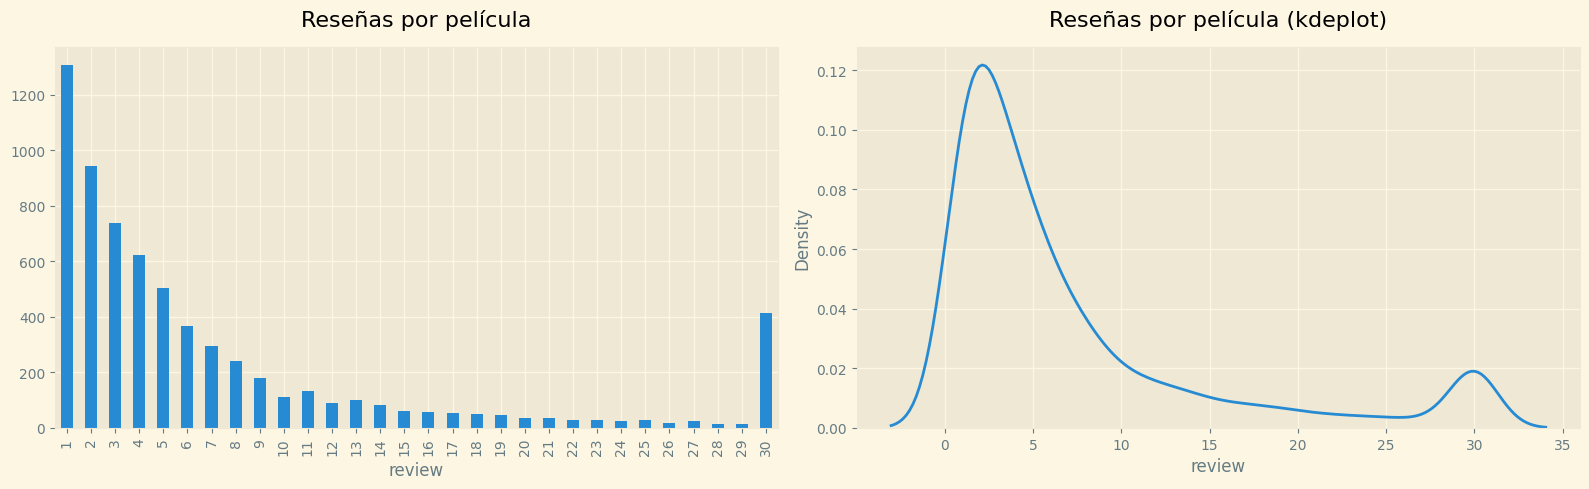

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Reseñas por película', pad=15)


ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Reseñas por película (kdeplot)', pad=15)

fig.tight_layout()


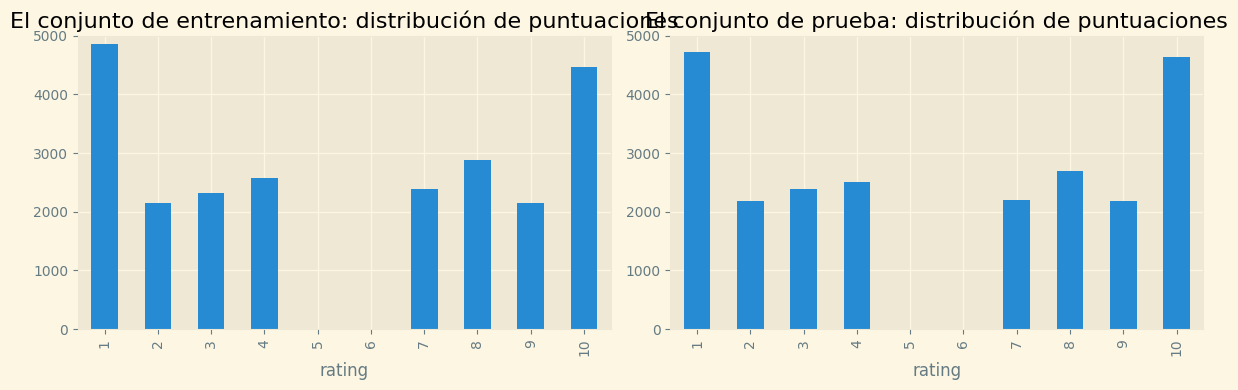

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('El conjunto de entrenamiento: distribución de puntuaciones')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('El conjunto de prueba: distribución de puntuaciones')

fig.tight_layout()


Distribución de reseñas negativas y positivas a lo largo de los años para dos partes del conjunto de datos

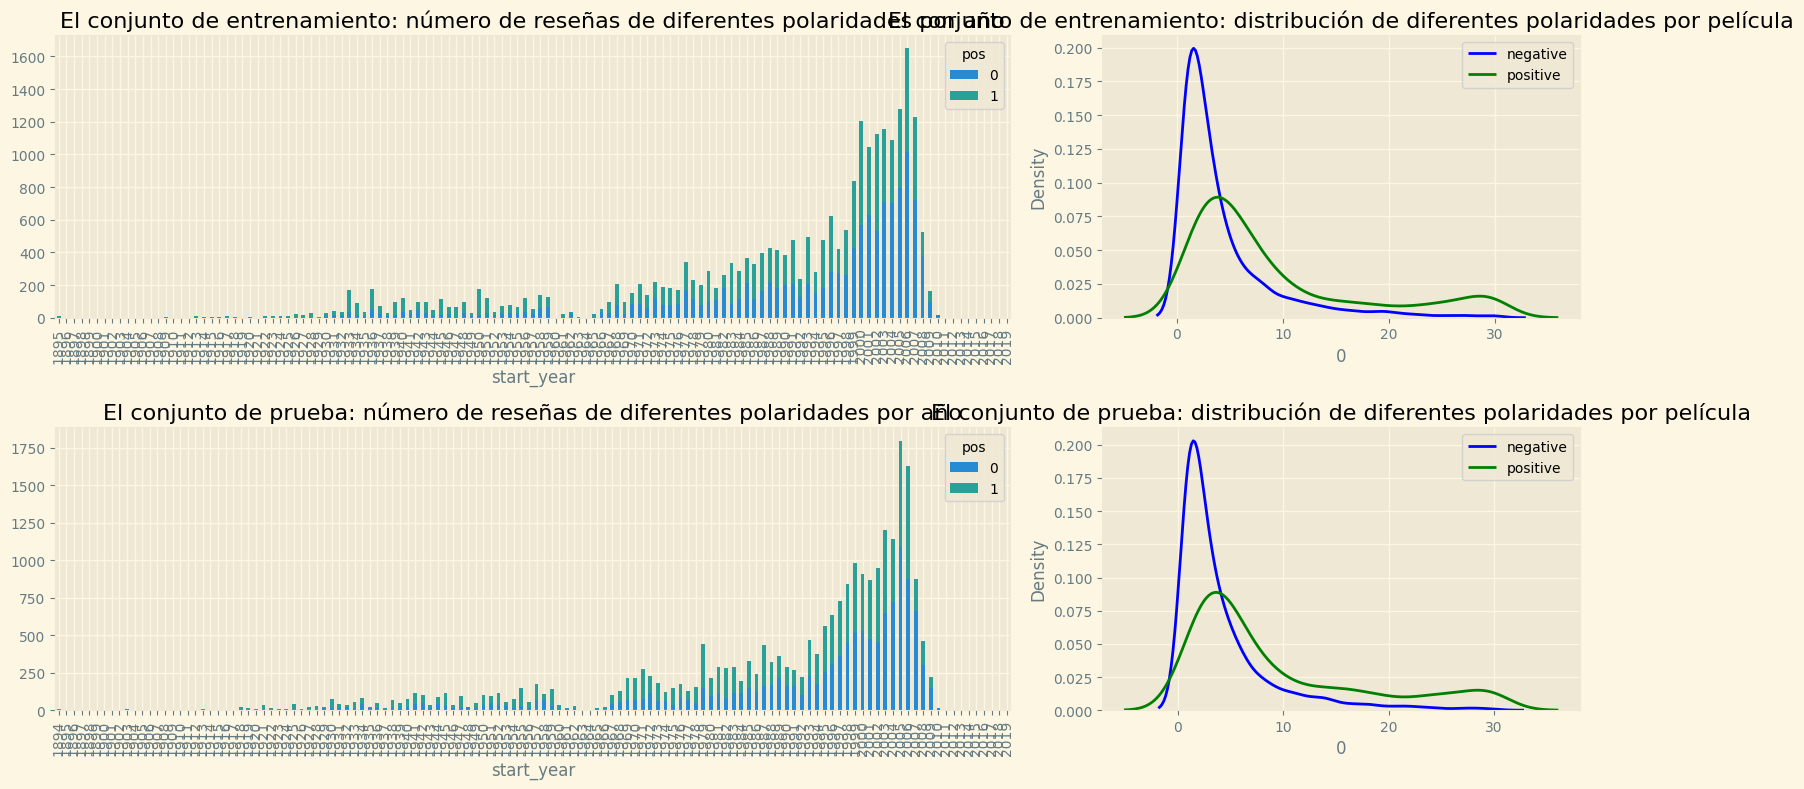

In [40]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()

dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)

dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('El conjunto de entrenamiento: número de reseñas de diferentes polaridades por año')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', ax=ax)
ax.legend()
ax.set_title('El conjunto de entrenamiento: distribución de diferentes polaridades por película')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('El conjunto de prueba: número de reseñas de diferentes polaridades por año')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', ax=ax)
ax.legend()
ax.set_title('El conjunto de prueba: distribución de diferentes polaridades por película')

fig.tight_layout()


## Comprehensive Model Evaluation and Threshold Analysis

In [1]:
import sklearn.metrics as metrics


def evaluate_model(model, train_features, train_target, test_features, test_target):

    eval_stats = {}

    fig, axs = plt.subplots(1, 3, figsize=(20, 6))

    for subset, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):

        eval_stats[subset] = {}

        pred_target = model.predict(features)
        
        # For LinearSVC, which does not have predict_proba, we can use decision_function to get the scores
        
        if hasattr(model, "predict_proba"):
            pred_proba = model.predict_proba(features)[:, 1]
        else:
            pred_proba = model.decision_function(features)
        
        # F1

        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]

        # ROC

        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)
        eval_stats[subset]['ROC AUC'] = roc_auc

        # PRC 
        
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[subset]['APS'] = aps

        if subset == 'train':
            color = 'blue'
        else:
            color = 'green'

        # Valor F1
        
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{subset}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Value')

        # ROC
        ax = axs[1]
        ax.plot(fpr, tpr, color=color, label=f'{subset}, ROC AUC={roc_auc:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')
        ax.set_title(f'ROC Curve')

        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{subset}, AP={aps:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'Precision-Recall Curve')

        eval_stats[subset]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[subset]['F1'] = metrics.f1_score(target, pred_target)

    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))

    print(df_eval_stats)

    return


## Dataset Partitioning Using a Predefined Train–Test Split

In [24]:

df_reviews_train = df_model[df_reviews.loc[df_model.index, 'ds_part'] == 'train']
df_reviews_test = df_model[df_reviews.loc[df_model.index, 'ds_part'] == 'test']


train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']


print(df_reviews_train.shape)
print(df_reviews_test.shape)


(23757, 2)
(23481, 2)


## Text Preprocessing: Basic Cleaning and Lemmatization

In [25]:

import re

corpus_train = df_reviews_train['review']
corpus_test = df_reviews_test['review']

def corpus_cleaned (corpus, desc="Processing"):
    
    cleaned_texts = []
    
    for review in tqdm(corpus, desc=desc):
        review = " ".join(re.sub(r"[^a-zA-Z']", " ", review).split()).lower()
        cleaned_texts.append(review)

    return cleaned_texts

train_clean = corpus_cleaned(corpus_train, "Train preprocessing")
test_clean = corpus_cleaned(corpus_test, "Test preprocessing")

np.save("train_cleaned.npy", train_clean)
np.save("test_cleaned.npy", test_clean)


Train preprocessing:   0%|          | 0/23757 [00:00<?, ?it/s]

Test preprocessing:   0%|          | 0/23481 [00:00<?, ?it/s]

In [29]:
import nltk
import spacy


nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])


def process_corpus(corpus, desc="Processing"):
    
    cleaned_texts = (
        " ".join(re.sub(r"[^a-zA-Z']", " ", review).split()).lower()
        for review in corpus
    )
    
    processed = []
    
    for doc in tqdm(nlp.pipe(cleaned_texts, batch_size=500),
                    desc=desc,
                    total=len(corpus)):
        
        lemmas = [token.lemma_ for token in doc]
        processed.append(" ".join(lemmas))
        
    return processed


train_lemmatized = process_corpus(corpus_train, "Train preprocessing")
test_lemmatized = process_corpus(corpus_test, "Test preprocessing")

np.save("train_lemmatized.npy", train_lemmatized)
np.save("test_lemmatized.npy", test_lemmatized)


Train preprocessing:   0%|          | 0/23757 [00:00<?, ?it/s]

Test preprocessing:   0%|          | 0/23481 [00:00<?, ?it/s]

In [29]:
# Normla version of BERT tokenizer

from transformers import AutoTokenizer, AutoModel
from transformers import logging


logging.set_verbosity_error()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased").to(device)
model.eval()

def get_embeddings(texts, batch_size=32, desc="Processing"):

    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc=desc):

        batch_texts = texts[i:i+batch_size]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        )

        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = model(**encoded)

        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu())

    return torch.cat(all_embeddings, dim=0).numpy()


train_embeddings = get_embeddings(corpus_train.tolist(), desc="Train")
test_embeddings = get_embeddings(corpus_test.tolist(), desc="Test")


np.save("train_embeddings.npy", train_embeddings)  
np.save("test_embeddings.npy", test_embeddings)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Train:   0%|          | 0/743 [00:00<?, ?it/s]

: 

In [12]:
train_clean = np.load(r"..\data\train_cleaned.npy", allow_pickle=True)
test_clean = np.load(r"..\data\test_cleaned.npy", allow_pickle=True)

train_lemmatized = np.load(r"..\data\train_lemmatized.npy", allow_pickle=True)
test_lemmatized = np.load(r"..\data\test_lemmatized.npy", allow_pickle=True)

train_embeddings = np.load(r"..\data\train_embeddings.npy", allow_pickle=True)
test_embeddings = np.load(r"..\data\test_embeddings.npy", allow_pickle=True)

print(train_clean.shape, test_clean.shape)
print(train_lemmatized.shape, test_lemmatized.shape)
print(train_embeddings.shape, test_embeddings.shape)

(23757,) (23481,)
(23757,) (23481,)
(23757, 768) (23481, 768)


## Model Development and Evaluation

In [26]:
# splitting data into features and target for both cleaned and lemmatized versions using the dataset "df_model"

from sklearn.feature_extraction.text import TfidfVectorizer


tfidf_basic = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9
)
    
X_train_basic = tfidf_basic.fit_transform(train_clean)
X_test_basic = tfidf_basic.transform(test_clean)


tfidf_lemm = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9
)

X_train_lemm = tfidf_lemm.fit_transform(train_lemmatized)
X_test_lemm = tfidf_lemm.transform(test_lemmatized)


y_train = train_target
y_test = test_target

print(X_train_basic.shape, X_test_basic.shape)
print(X_train_lemm.shape, X_test_lemm.shape)


(23757, 148673) (23481, 148673)
(23757, 135413) (23481, 135413)


### Baseline Text-Based Modeling and Hyperparameter Optimization

In [27]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import RandomizedSearchCV, ParameterGrid

best_params = {}

def train_eval_with_search(model, param_grid,
                           X_train, X_test,
                           y_train, y_test,
                           model_name="Model"):

    print(f"\n===== {model_name} =====")

    if not param_grid:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        print(f"\nBest {model_name} F1 Score: {metrics.f1_score(y_test, preds):.2f} \n")
        print("Best params: {}")
        evaluate_model(model, X_train, y_train, X_test, y_test)
        return

    total_params = len(ParameterGrid(param_grid))
    actual_iter = min(10, total_params)
    
    search = RandomizedSearchCV(
        model,
        param_distributions=param_grid,
        n_iter=actual_iter,
        cv=5,
        scoring="f1",
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_train, y_train)
    
    best_model = search.best_estimator_
    preds = best_model.predict(X_test)
    
    print(f"\nBest {model_name} F1 Score: {metrics.f1_score(y_test, preds):.2f} \n")

    print("Best params:", search.best_params_)
    best_params[model_name] = search.best_params_

    evaluate_model(best_model, X_train, y_train, X_test, y_test)
     

La función train_eval_with_search realiza el entrenamiento del modelo y la optimización de hiperparámetros utilizando RandomizedSearchCV (a excepción del clasificador Dummy, que no requiere ajuste). Para cada modelo, la función lleva a cabo una búsqueda de parámetros mediante validación cruzada para identificar la mejor configuración de hiperparámetros basada en la métrica F1.

Una vez seleccionados los parámetros óptimos, el mejor estimador se evalúa con el conjunto de prueba. El rendimiento se evalúa utilizando la métrica F1 y se analiza más a fondo a través de la función evaluate_model, la cual proporciona diagnósticos visuales que incluyen:

1. Puntuaciones F1 a través de diferentes umbrales de clasificación.

2. Curva de Característica Operativa del Receptor (ROC).

3. Curva de Precisión-Recall (PRC).

Este enfoque garantiza una comparación consistente y justa entre los modelos, ofreciendo tanto métricas cuantitativas como información gráfica sobre el desempeño de la clasificación.

In [28]:
# Relevant parameters for tuning each model

dummy_params = {}  # no tuning

nb_params = {
    "alpha": [0.1, 0.5, 1.0]
}

logreg_params = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

svm_params = {
    "C": [0.01, 0.1, 1, 10]
}



===== Dummy =====

Best Dummy F1 Score: 0.00 

Best params: {}
          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5

===== MultinomialNB =====

Best MultinomialNB F1 Score: 0.87 

Best params: {'alpha': 0.5}
          train  test
Accuracy   0.94  0.87
F1         0.94  0.87
APS        0.99  0.94
ROC AUC    0.99  0.94

===== LogReg =====

Best LogReg F1 Score: 0.90 

Best params: {'solver': 'liblinear', 'C': 10}
          train  test
Accuracy    1.0  0.90
F1          1.0  0.90
APS         1.0  0.96
ROC AUC     1.0  0.96

===== SVM =====

Best SVM F1 Score: 0.90 

Best params: {'C': 1}
          train  test
Accuracy    1.0  0.90
F1          1.0  0.90
APS         1.0  0.96
ROC AUC     1.0  0.96


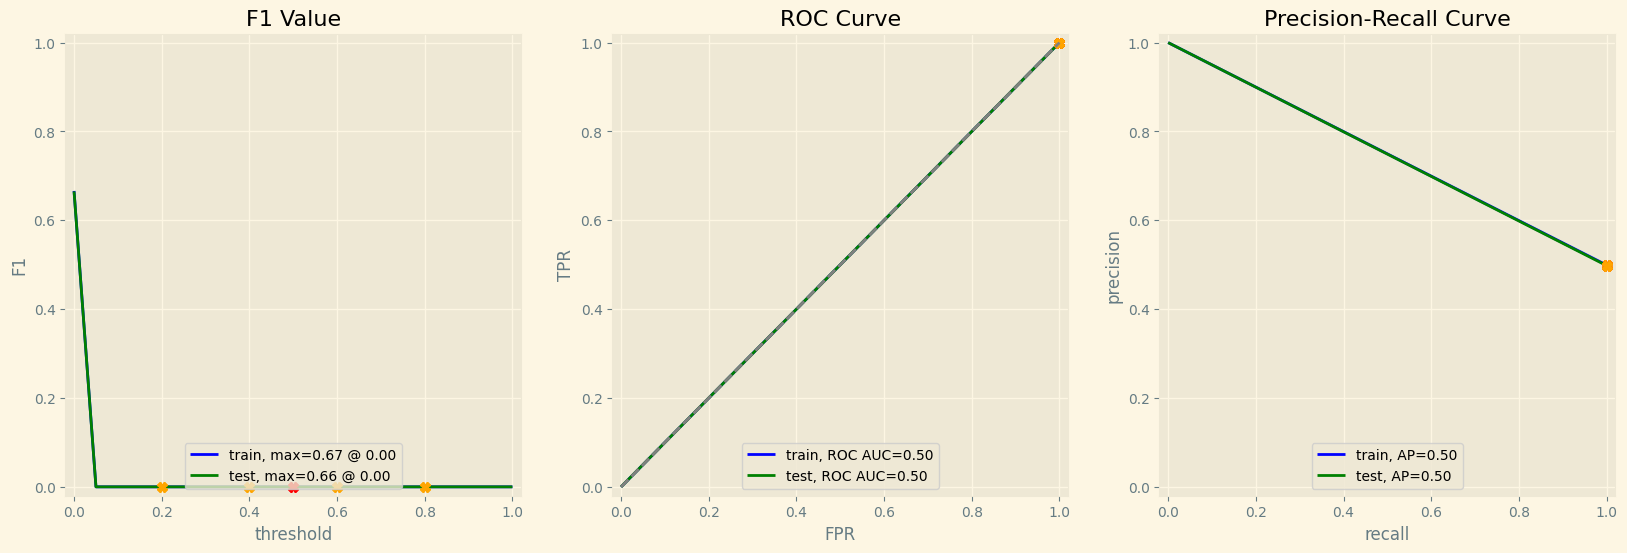

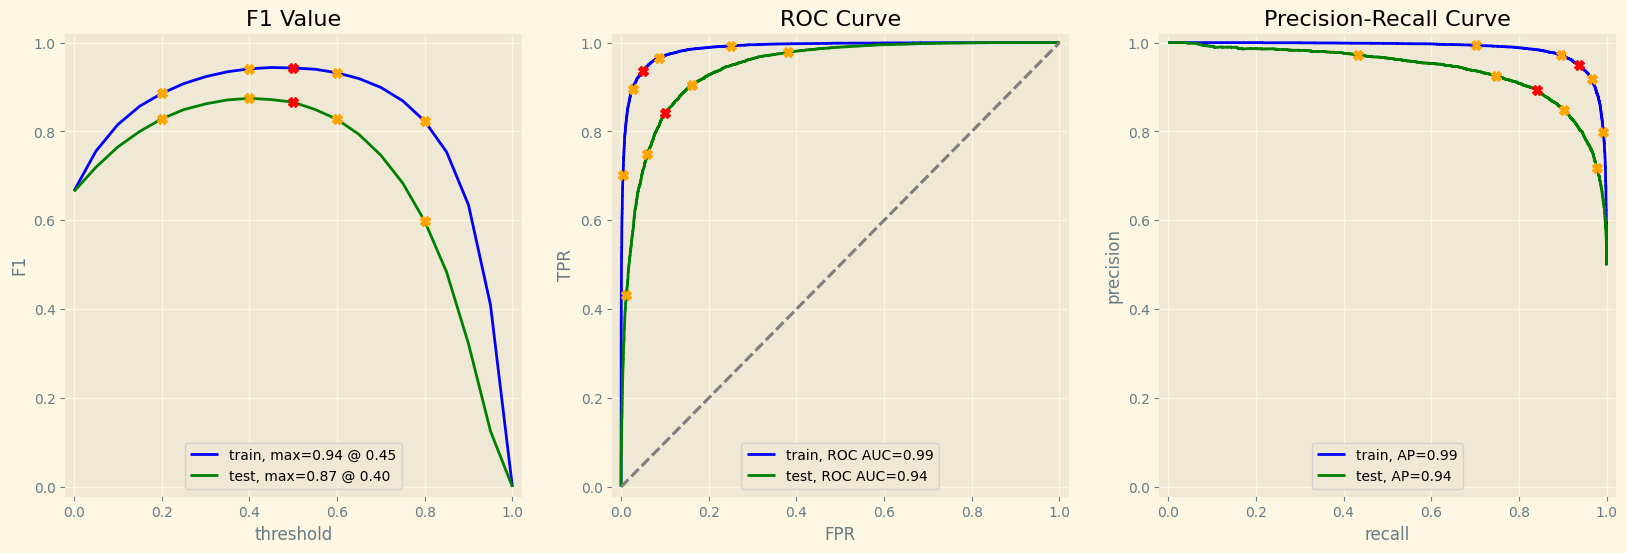

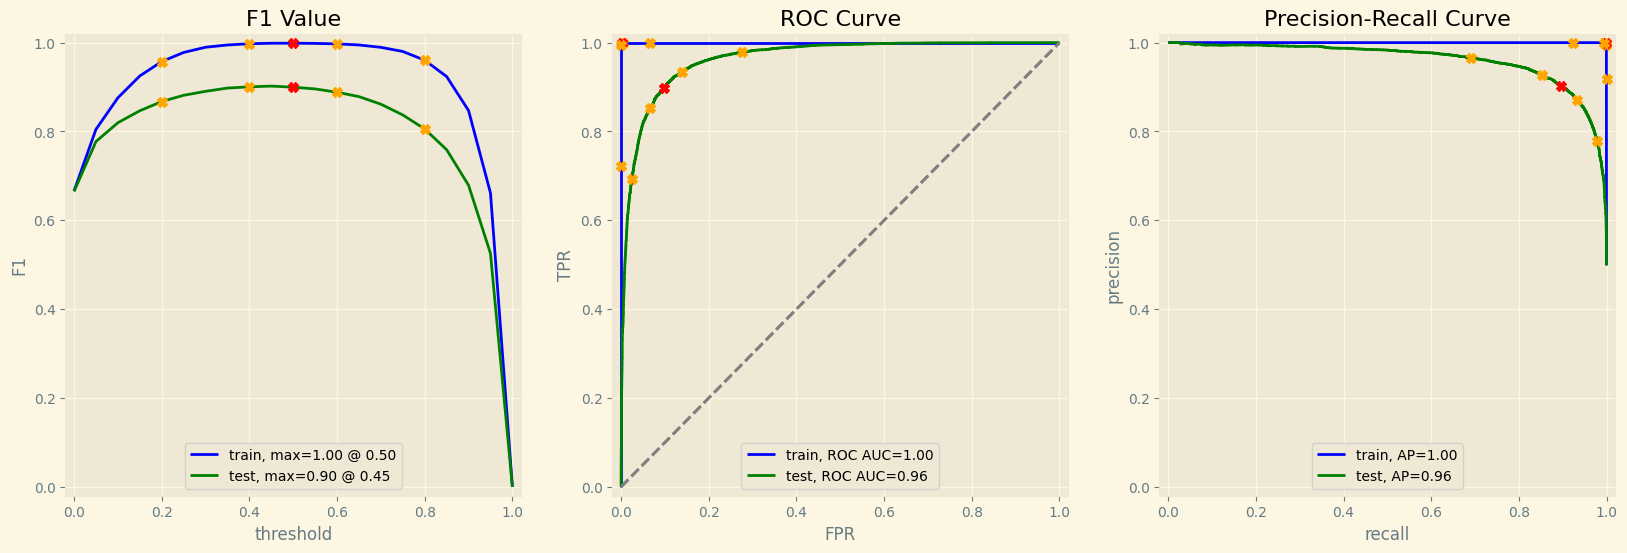

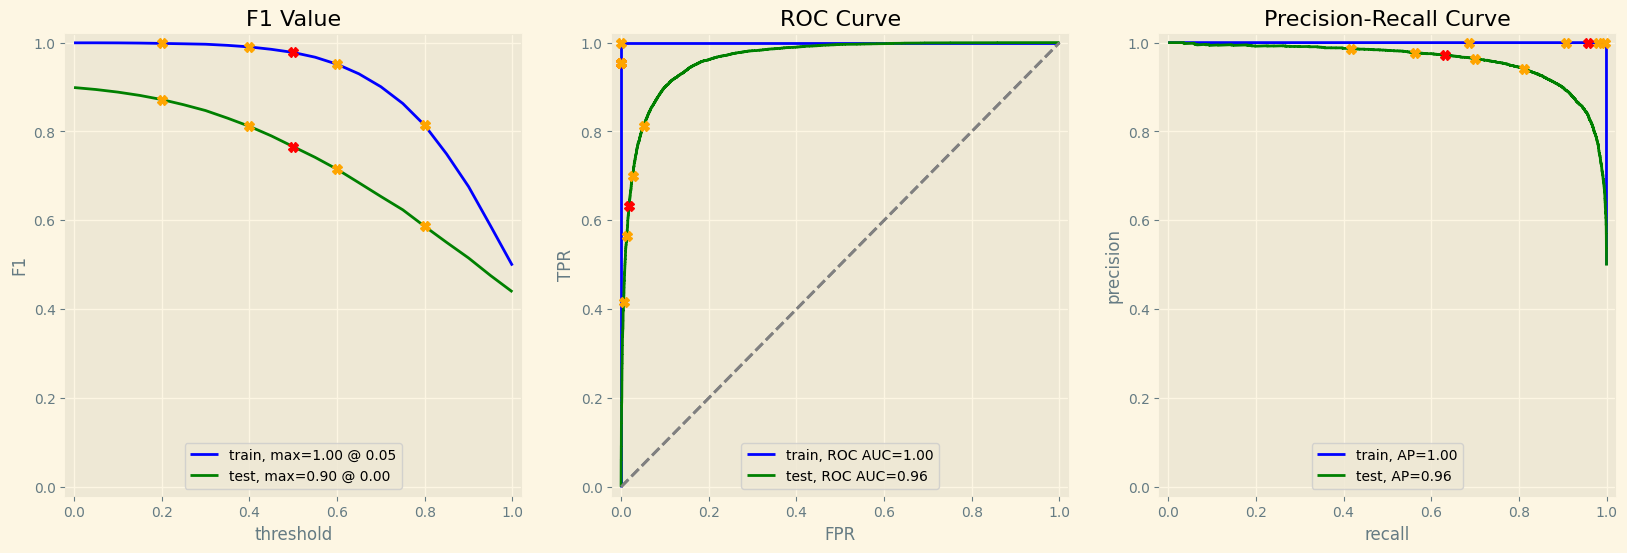

In [29]:
# Model Evaluation on Cleaned Text (Unigrams and Bigrams, No Lemmatization)

models = [
    ("Dummy", DummyClassifier(strategy="most_frequent"), dummy_params),
    ("MultinomialNB", MultinomialNB(), nb_params),
    ("LogReg", LogisticRegression(max_iter=1000), logreg_params),
    ("SVM", LinearSVC(), svm_params)
]
_
for name, model, params in models:
    train_eval_with_search(
        model,
        params,
        X_train_basic,
        X_test_basic,
        y_train,
        y_test,
        model_name=name
    )
    

In [4]:
# Model Evaluation on Lemmatized Text as well as unigrams and bigrams

for name, model, params in models:
    train_eval_with_search(
        model,
        params,
        X_train_lemm,
        X_test_lemm,    
        y_train,
        y_test,
        model_name=name
    )
    

NameError: name 'models' is not defined

### Feature-Enriched Modeling and Hyperparameter Optimization

In [ ]:
# splitting data into features and target for both cleaned and lemmatized versions using the dataset "df_model_extended"

df_extended_train_basic = df_model_extended[df_reviews.loc[df_model_extended.index, 'ds_part'] == 'train']
df_extended_test_basic = df_model_extended[df_reviews.loc[df_model_extended.index, 'ds_part'] == 'test']

y_train = df_extended_train_basic['pos']
y_test = df_extended_test_basic['pos']

print(df_extended_train_basic.shape)
print(df_extended_test_basic.shape)


(23757, 5)
(23481, 5)


In [ ]:
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer

# Genres
genre_vectorizer = CountVectorizer(
    tokenizer=lambda x: x.split(','),
    token_pattern=None,
    binary=True
)

X_train_genres_basic = genre_vectorizer.fit_transform(df_extended_train_basic['genres'])
X_test_genres_basic = genre_vectorizer.transform(df_extended_test_basic['genres'])

# Numeric
scaler = StandardScaler()
X_train_num = scaler.fit_transform(df_extended_train_basic[['average_rating', 'votes']])
X_test_num = scaler.transform(df_extended_test_basic[['average_rating', 'votes']])

X_train_num_sparse_basic = csr_matrix(X_train_num)
X_test_num_sparse_basic = csr_matrix(X_test_num)

# Combine basic tokenized features with genres and numeric features
X_extend_train_basic = hstack([X_train_basic, X_train_genres_basic, X_train_num_sparse_basic])
X_extend_test_basic = hstack([X_test_basic, X_test_genres_basic, X_test_num_sparse_basic])

# Combine lemmatized and tokenized reviews with genres and numeric features
X_extend_train_lemm = hstack([X_train_lemm, X_train_genres_basic, X_train_num_sparse_basic])
X_extend_test_lemm = hstack([X_test_lemm, X_test_genres_basic, X_test_num_sparse_basic])


print(X_extend_train_basic.shape, X_extend_test_basic.shape)
print(X_extend_train_lemm.shape, X_extend_test_lemm.shape)


(23757, 148704) (23481, 148704)
(23757, 135444) (23481, 135444)


Con el objetivo de enriquecer el modelo, se incorporaron variables estructuradas adicionales a la representación textual. La variable genres fue transformada mediante CountVectorizer con binary=True, generando una codificación binaria donde cada género se representa como una característica independiente.

Las variables numéricas (average_rating y votes) fueron estandarizadas utilizando StandardScaler para garantizar escalas comparables entre características.

Finalmente, las representaciones textuales (tanto en su versión básica como lematizada) se combinaron mediante concatenación horizontal con las variables de género y las numéricas escaladas, obteniendo así una matriz de características extendida. Cabe destacar que las variables estructuradas son idénticas en ambas versiones, variando únicamente el preprocesamiento aplicado al texto.


===== Dummy =====

Best Dummy F1 Score: 0.00 

Best params: {}
          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5

===== LogReg =====

Best LogReg F1 Score: 0.91 

Best params: {'solver': 'lbfgs', 'C': 10}
          train  test
Accuracy    1.0  0.91
F1          1.0  0.91
APS         1.0  0.97
ROC AUC     1.0  0.97

===== SVM =====

Best SVM F1 Score: 0.91 

Best params: {'C': 1}
          train  test
Accuracy    1.0  0.91
F1          1.0  0.91
APS         1.0  0.97
ROC AUC     1.0  0.97


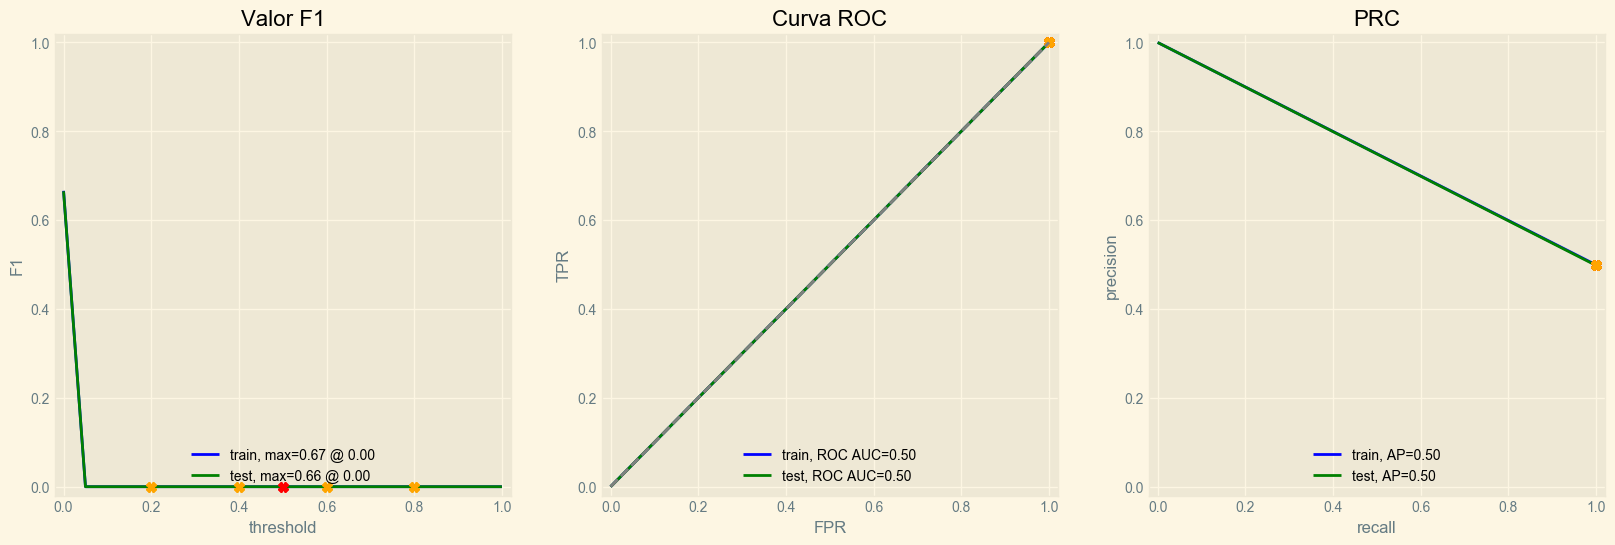

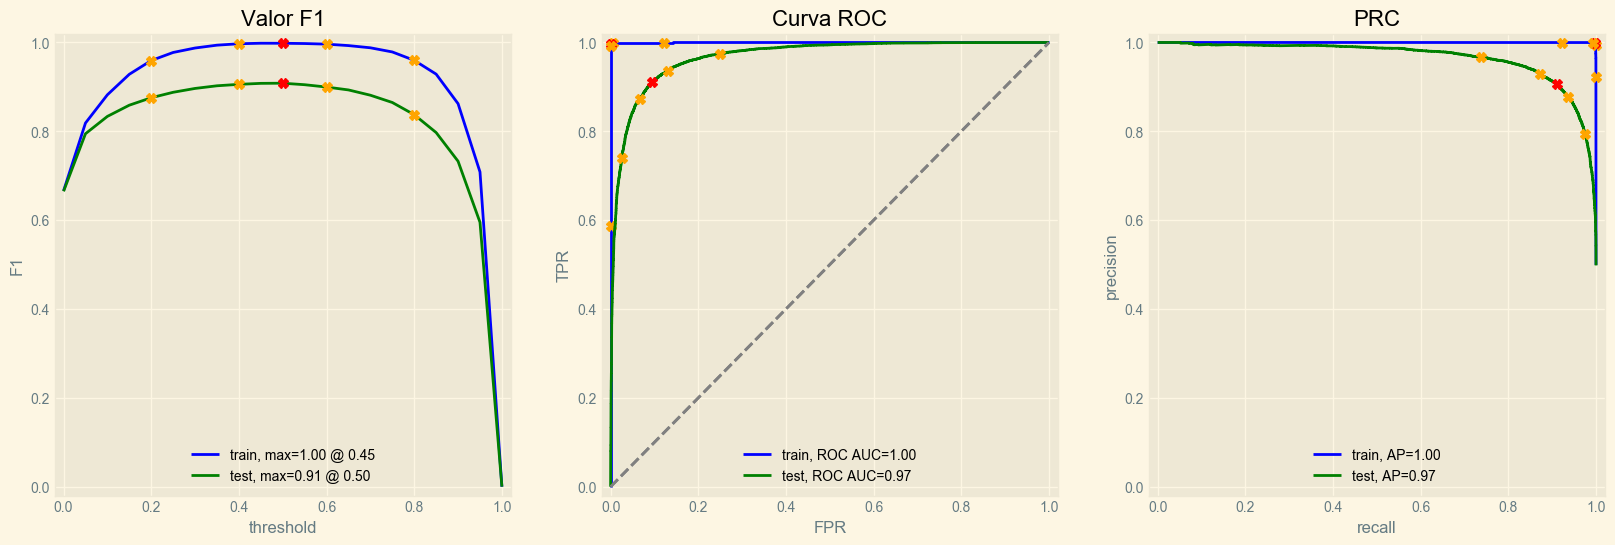

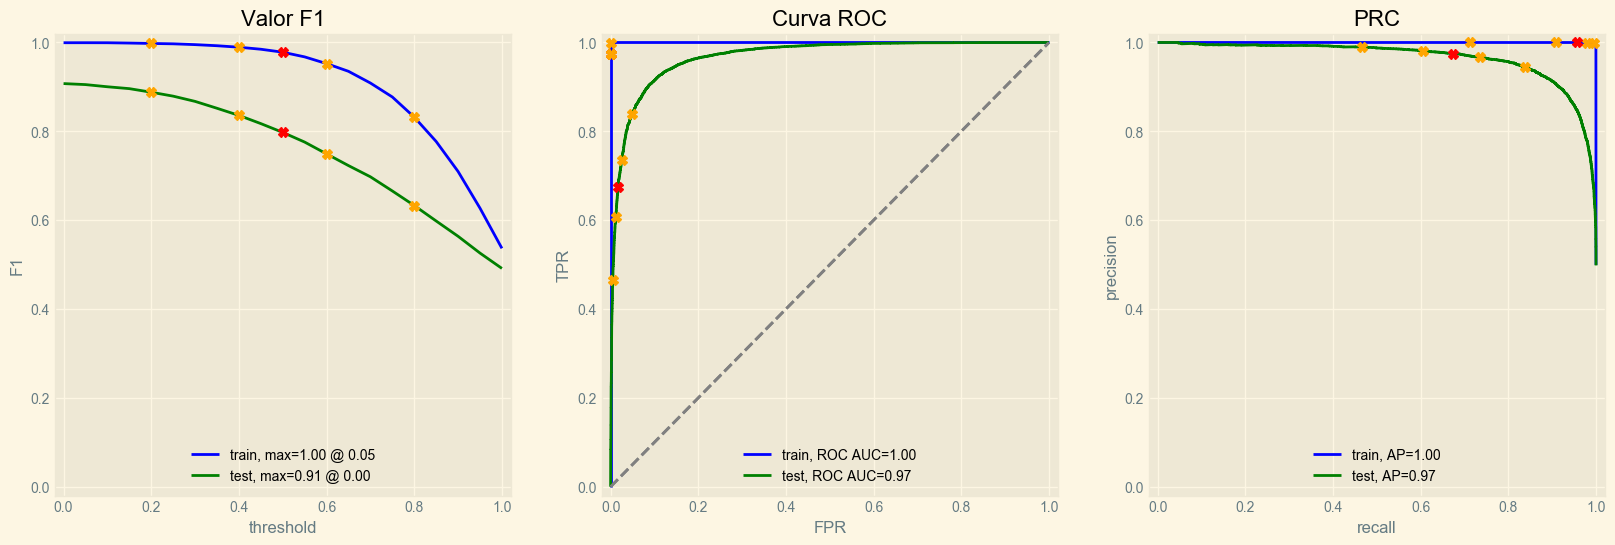

In [ ]:
# Model Evaluation on Cleaned Text (Unigrams and Bigrams, No Lemmatization)

models_v2 = [
    ("Dummy", DummyClassifier(strategy="most_frequent"), dummy_params),
    ("LogReg", LogisticRegression(max_iter=1000), logreg_params),
    ("SVM", LinearSVC(max_iter=5000), svm_params)
]

for name, model, params in models_v2:
    train_eval_with_search(
        model,
        params,
        X_extend_train_basic,
        X_extend_test_basic,
        y_train,
        y_test,
        model_name=name
    )

En el experimento extendido no se utilizó Multinomial Naive Bayes, ya que este modelo asume características basadas en conteos no negativos. La incorporación de variables numéricas escaladas (que pueden tomar valores negativos) viola dicho supuesto. Además, MultinomialNB está especialmente diseñado para representaciones tipo bag-of-words, por lo que modelos discriminativos como Logistic Regression resultan más adecuados para combinar texto y variables estructuradas.


===== Dummy =====

Best Dummy F1 Score: 0.00 

Best params: {}
          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5

===== LogReg =====

Best LogReg F1 Score: 0.91 

Best params: {'solver': 'lbfgs', 'C': 10}
          train  test
Accuracy    1.0  0.91
F1          1.0  0.91
APS         1.0  0.97
ROC AUC     1.0  0.97

===== SVM =====

Best SVM F1 Score: 0.91 

Best params: {'C': 1}
          train  test
Accuracy    1.0  0.91
F1          1.0  0.91
APS         1.0  0.97
ROC AUC     1.0  0.97


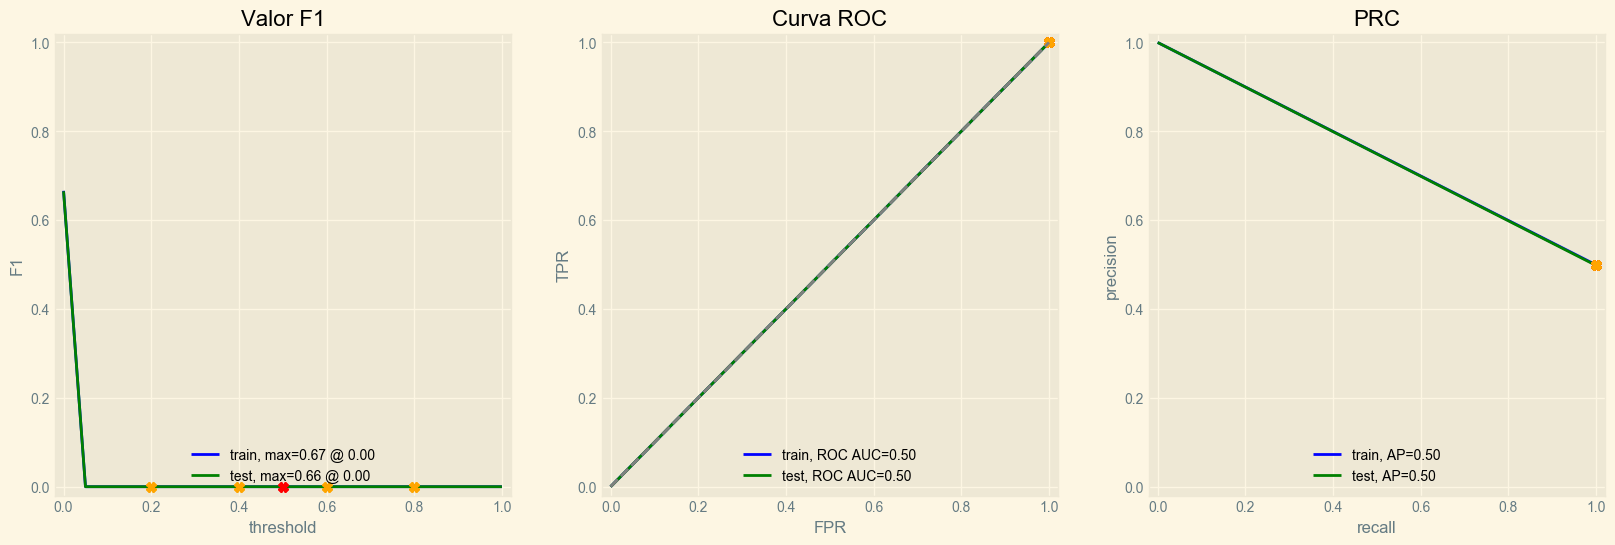

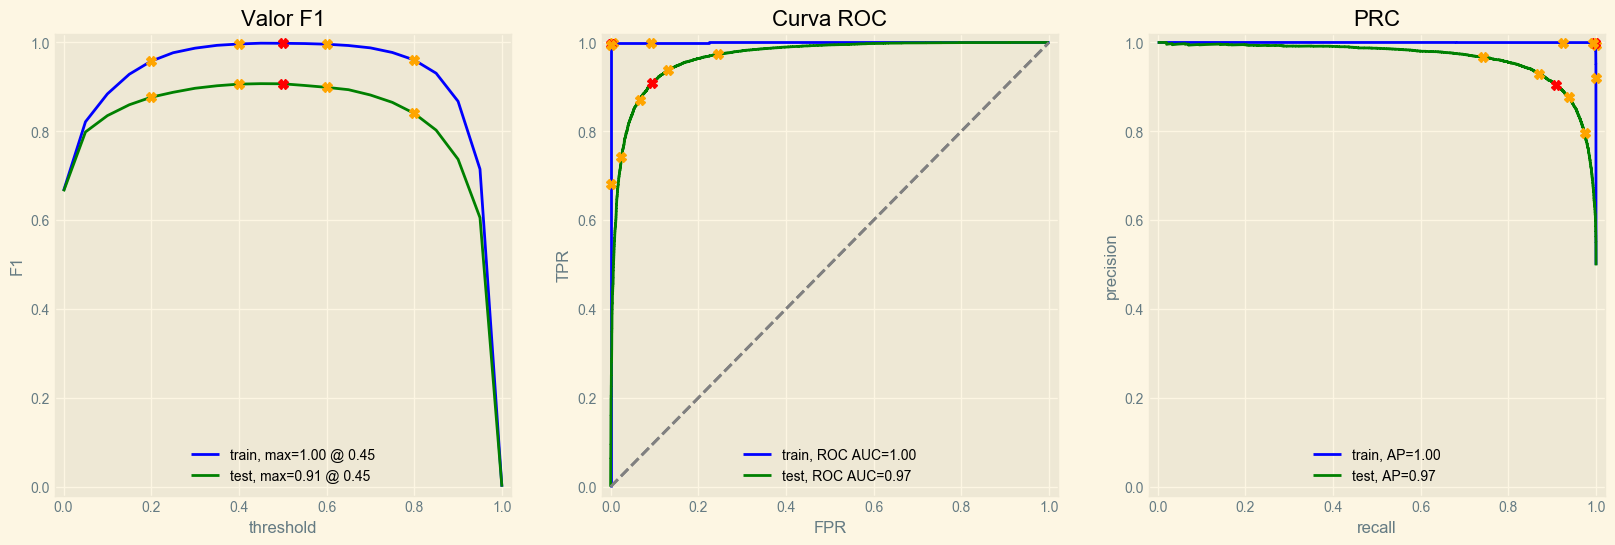

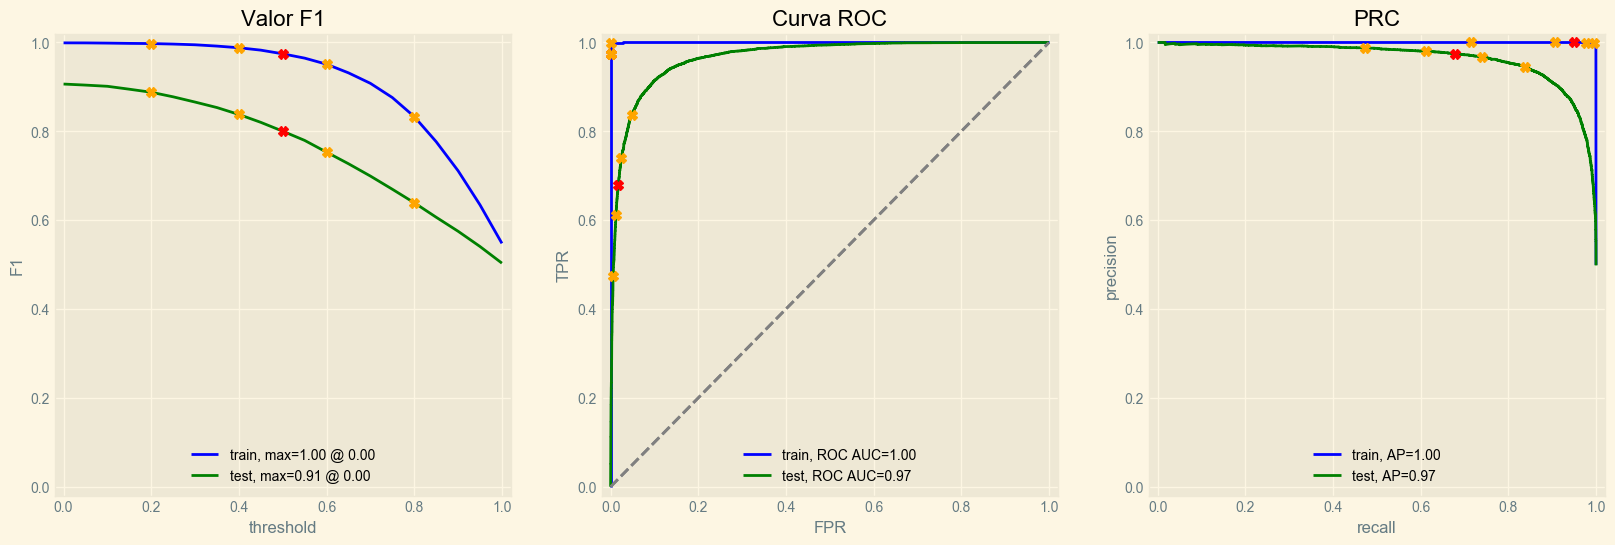

In [ ]:
# Model Evaluation on Lemmatized Text as well as unigrams and bigrams

for name, model, params in models_v2:
    train_eval_with_search(
        model,
        params,
        X_extend_train_lemm,
        X_extend_test_lemm,
        y_train,
        y_test,
        model_name=name
    )

## Counclusion

El presente proyecto abordó la tarea de clasificación binaria de sentimiento a partir de reseñas textuales de películas, mediante un enfoque experimental estructurado que incluyó partición controlada del conjunto de datos, preprocesamiento sistemático, ingeniería de características, optimización de hiperparámetros y evaluación exhaustiva del desempeño.

El modelo base, construido únicamente sobre representaciones TF-IDF del texto limpio utilizando unigramas y bigramas, alcanzó un desempeño sólido (F1 = 0.90; ROC AUC = 0.96 en el conjunto de prueba). La incorporación de lematización no produjo mejoras significativas, lo que indica que la representación léxica original era suficiente para capturar la señal de sentimiento presente en los datos.

Asimismo, se evaluó una versión extendida que incorporó variables estructuradas adicionales (géneros y características numéricas escaladas). Si bien esta configuración generó una ligera mejora, el impacto fue marginal, lo que sugiere que el contenido textual constituye la principal fuente de información predictiva.

Entre los modelos evaluados, tanto Logistic Regression como Linear SVM alcanzaron un rendimiento equivalente. No obstante, se seleccionó Logistic Regression como modelo final debido a su capacidad para producir probabilidades calibradas, su mayor interpretabilidad y su amplio reconocimiento como línea base sólida en tareas de clasificación de texto.

En conjunto, los resultados demuestran que enfoques clásicos basados en modelos lineales continúan siendo altamente competitivos en tareas de análisis de sentimiento cuando se combinan con un diseño experimental riguroso y una adecuada representación textual.

Como línea futura de trabajo, podría explorarse el uso de modelos basados en representaciones contextuales, como arquitecturas tipo Transformer, con el fin de evaluar posibles mejoras adicionales sobre la línea base establecida.